In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from PIL import Image
import cv2
import glob
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (12, 6)
#掩码处理
def rle_decode(mask_rle, shape):

    if pd.isna(mask_rle) or mask_rle == '':
        return np.zeros(shape, dtype=np.uint8)
        
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape)


# loss 与 dice
class BCEDiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super().__init__()

    def forward(self, inputs, targets, smooth=1):
        # BCE 部分
        bce_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        
        # Dice 部分
        inputs = torch.sigmoid(inputs)       
        
        # Flatten
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        # 组合 Loss (0.5 BCE + 0.5 Dice)
        return 0.5 * bce_loss + 0.5 * dice_loss

In [ ]:
class MedicalImageSegmentationDataset(Dataset):
    def __init__(self, data_root, df, class_names=['large_bowel', 'small_bowel', 'stomach'], transform=None, is_train=True):


        self.data_root = data_root
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.transform = transform
        self.is_train = is_train
        
        self.df = df
        # 按 id 分组
        self.grouped_df = self.df.groupby('id') 
        self.ids = list(self.grouped_df.groups.keys())
        
        # 构建 id 到文件路径的映射
        self.id_to_path = self._build_image_path_map() 
        
        # 过滤掉找不到文件的 ID
        self.ids = [id_ for id_ in self.ids if id_ in self.id_to_path]
        print(f"{'Train' if is_train else 'Val'} Dataset: Found {len(self.ids)} samples.")

    def _build_image_path_map(self):

        id_to_path = {}
        search_dir = os.path.join(self.data_root, 'train')
        
        # 递归搜索所有 png 文件 
        print("Building file map... (this might take a moment)")
        # 使用 glob 匹配所有 png
        all_files = glob.glob(os.path.join(search_dir, "**", "*.png"), recursive=True)
        
        for file_path in all_files:
            # 解析路径获取元数据
            path_parts = file_path.split(os.sep)
            
            try:
                # 倒数第3级目录
                case_day_dir = path_parts[-3] # 'case123_day20'
                if not case_day_dir.startswith('case'): continue
                
                parts = case_day_dir.split('_')
                case_str = parts[0] # case123
                day_str = parts[1]  # day20
                
                file_name = os.path.basename(file_path)
                slice_str = "_".join(file_name.split('_')[:2]) # slice_0001
                
                # 构造 ID
                generated_id = f"{case_str}_{day_str}_{slice_str}"
                
                # 只有当这个 ID 在我们传入的 DataFrame 中时才记录
                if generated_id in self.grouped_df.groups:
                    id_to_path[generated_id] = file_path
            except:
                continue
                
        return id_to_path

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        image_path = self.id_to_path[image_id]
        
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        
        if img is None:
             raise FileNotFoundError(f"Failed to read image via cv2: {image_path}")
        
        # 16-bit 归一化到 0-1 float32
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        
        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=-1)
            
        original_size = img.shape[:2] # (H, W)


        # 处理 Mask
        masks_combined = np.zeros((self.num_classes, original_size[0], original_size[1]), dtype=np.float32)
        group_data = self.grouped_df.get_group(image_id) 
        
        for i, cls_name in enumerate(self.class_names):
            row = group_data[group_data['class'] == cls_name]
            if not row.empty and pd.notna(row.iloc[0]['segmentation']) and row.iloc[0]['segmentation'] != '':
                mask_rle = row.iloc[0]['segmentation']
                mask_single_class = rle_decode(mask_rle, original_size)
                masks_combined[i] = mask_single_class.astype(np.float32)
        
        # Data Augmentation / Transforms
        # 手动转 Tensor [H, W, C] -> [C, H, W]
        image_tensor = torch.from_numpy(img).permute(2, 0, 1) # [1, H, W]
        mask_tensor = torch.from_numpy(masks_combined) # [C, H, W]

        if self.transform:
            # 简单处理 resize
            image_tensor = self.transform(image_tensor)
            # Mask Resize
            mask_tensor_resized = []
            new_h, new_w = image_tensor.shape[-2:]
            for c in range(mask_tensor.shape[0]):
                 # 转 PIL resize 再转回 (简单做法)
                 m_pil = transforms.ToPILImage()(mask_tensor[c])
                 m_pil = m_pil.resize((new_w, new_h), resample=Image.NEAREST)
                 mask_tensor_resized.append(transforms.ToTensor()(m_pil).squeeze(0))
            mask_tensor = torch.stack(mask_tensor_resized)

        return image_tensor, mask_tensor

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, padding=1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_block = ConvBlock(in_channels + skip_channels, out_channels)
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            # 简单的 crop/pad 处理尺寸不匹配
            diffY = skip.size()[2] - x.size()[2]
            diffX = skip.size()[3] - x.size()[3]
            x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
            x = torch.cat([skip, x], dim=1)
        x = self.conv_block(x)
        return x

class UNetWithResNet34Encoder(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super(UNetWithResNet34Encoder, self).__init__()
        self.n_classes = n_classes
        
        # 1. 导入 ResNet34
        resnet = models.resnet34(weights='IMAGENET1K_V1' if pretrained else None)
        
        # 2. 修改第一层 (适应单通道输入: 1 channel -> 64 channels)
        original_weights = resnet.conv1.weight.data
        self.new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            # 将 RGB 权重的平均值赋值给单通道
            self.new_conv1.weight.data = original_weights.mean(dim=1, keepdim=True)
        
        self.encoder0 = nn.Sequential(self.new_conv1, resnet.bn1, resnet.relu)
        self.encoder1 = nn.Sequential(resnet.maxpool, resnet.layer1)
        self.encoder2 = resnet.layer2
        self.encoder3 = resnet.layer3
        self.encoder4 = resnet.layer4
        
        # Decoder Layers
        self.decoder4 = DecoderBlock(512, 256, 256)
        self.decoder3 = DecoderBlock(256, 128, 128)
        self.decoder2 = DecoderBlock(128, 64, 64)
        self.decoder1 = DecoderBlock(64, 64, 64)
        
        self.upsample_final = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.final_conv_block = ConvBlock(64, 64)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

        # --- 修改点 2: 初始冻结 Encoder 权重 ---
        self.freeze_encoder()

    def freeze_encoder(self):
        """冻结 Encoder 部分的梯度"""
        print("Freezing Encoder weights...")
        for param in self.encoder0.parameters(): param.requires_grad = False
        for param in self.encoder1.parameters(): param.requires_grad = False
        for param in self.encoder2.parameters(): param.requires_grad = False
        for param in self.encoder3.parameters(): param.requires_grad = False
        for param in self.encoder4.parameters(): param.requires_grad = False

    def unfreeze_encoder(self):
        """解冻 Encoder 部分的梯度"""
        print("Unfreezing Encoder weights...")
        for param in self.encoder0.parameters(): param.requires_grad = True
        for param in self.encoder1.parameters(): param.requires_grad = True
        for param in self.encoder2.parameters(): param.requires_grad = True
        for param in self.encoder3.parameters(): param.requires_grad = True
        for param in self.encoder4.parameters(): param.requires_grad = True

    def forward(self, x):
        # Encoder
        enc0 = self.encoder0(x)
        enc1 = self.encoder1(enc0)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        enc4 = self.encoder4(enc3)

        # Decoder (with skip connections)
        dec4 = self.decoder4(enc4, enc3)
        dec3 = self.decoder3(dec4, enc2)
        dec2 = self.decoder2(dec3, enc1)
        dec1 = self.decoder1(dec2, enc0)
        
        out = self.upsample_final(dec1)
        out = self.final_conv_block(out)
        out = self.final_conv(out)
        return out

In [ ]:
def multiclass_dice_coeff(pred_logits, target_masks, smooth=1e-6):
    pred_probs = torch.sigmoid(pred_logits)
    pred_flat = pred_probs.view(pred_probs.size(0), pred_probs.size(1), -1)
    target_flat = target_masks.view(target_masks.size(0), target_masks.size(1), -1)
    intersection = (pred_flat * target_flat).sum(dim=2)
    union = pred_flat.sum(dim=2) + target_flat.sum(dim=2)
    return ((2. * intersection + smooth) / (union + smooth)).mean()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        dice = multiclass_dice_coeff(outputs, masks)
        running_loss += loss.item()
        running_dice += dice.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})
        
    return running_loss / len(loader), running_dice / len(loader)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for imgs, masks in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            dice = multiclass_dice_coeff(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})
            
    return running_loss / len(loader), running_dice / len(loader)

def visualize_prediction_rgb(model, dataset, device, num_samples=3):
    model.eval()
    # 随机选择索引，实现随机抽取
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # 类别颜色
    colors = [np.array([1.0, 0.0, 0.0]), np.array([0.0, 1.0, 0.0]), np.array([0.0, 0.0, 1.0])]
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1: axes = [axes]
    
    for i, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]
        
        # 原图 (灰度转 RGB)
        img_np = img_tensor.squeeze().numpy()
        img_rgb = np.stack([img_np]*3, axis=-1)
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-6)
        
        # GT 叠加
        gt_vis = img_rgb.copy()
        mask_np = mask_tensor.numpy()
        for c in range(3):
            gt_vis[mask_np[c] > 0.5] = 0.6 * gt_vis[mask_np[c] > 0.5] + 0.4 * colors[c]
            
        # 预测叠加
        inp = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = torch.sigmoid(model(inp)).cpu().numpy()[0]
        
        pred_vis = img_rgb.copy()
        for c in range(3):
            pred_vis[pred[c] > 0.5] = 0.6 * pred_vis[pred[c] > 0.5] + 0.4 * colors[c]
            
        axes[i][0].imshow(img_rgb)
        axes[i][0].set_title(f"Original (ID: {dataset.ids[idx]})")
        axes[i][1].imshow(gt_vis)
        axes[i][1].set_title("Ground Truth (R/G/B)")
        axes[i][2].imshow(pred_vis)
        axes[i][2].set_title("Prediction")
        
    plt.tight_layout()
    plt.show()

def plot_training_history(history):

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Dice 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_dice'], 'b-o', label='Train Dice')
    plt.plot(epochs, history['val_dice'], 'r-o', label='Val Dice')
    plt.title('Training and Validation Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cuda
Total Cases: 85
Train Cases: 68, Val Cases: 17
Building file map... (this might take a moment)
Train Dataset: Found 30608 samples.
Building file map... (this might take a moment)
Val Dataset: Found 7888 samples.
Freezing Encoder weights...

Epoch 1/50


Train - Loss: 0.2511, Dice: 0.1400
Val   - Loss: 0.3370, Dice: 0.1740
Saved Best Model! (Loss: 0.3370)

Epoch 2/50


Train - Loss: 0.1330, Dice: 0.2064
Val   - Loss: 0.3102, Dice: 0.1999
Saved Best Model! (Loss: 0.3102)

Epoch 3/50


Train - Loss: 0.1105, Dice: 0.2203
Val   - Loss: 0.3081, Dice: 0.1936
Saved Best Model! (Loss: 0.3081)

Epoch 4/50


Train - Loss: 0.0998, Dice: 0.2270
Val   - Loss: 0.2984, Dice: 0.2047
Saved Best Model! (Loss: 0.2984)

Epoch 5/50


...

Train - Loss: 0.0383, Dice: 0.2669
Val   - Loss: 0.1422, Dice: 0.2019

Epoch 47/50


Train - Loss: 0.0380, Dice: 0.2671
Val   - Loss: 0.1459, Dice: 0.2070

Epoch 48/50


Train - Loss: 0.0372, Dice: 0.2682
Val   - Loss: 0.1413, Dice: 0.2075
Saved Best Model! (Loss: 0.1413)

Epoch 49/50


Train - Loss: 0.0364, Dice: 0.2683
Val   - Loss: 0.1453, Dice: 0.2117

Epoch 50/50


Train - Loss: 0.0365, Dice: 0.2684
Val   - Loss: 0.1198, Dice: 0.2092
Saved Best Model! (Loss: 0.1198)

Training Complete.


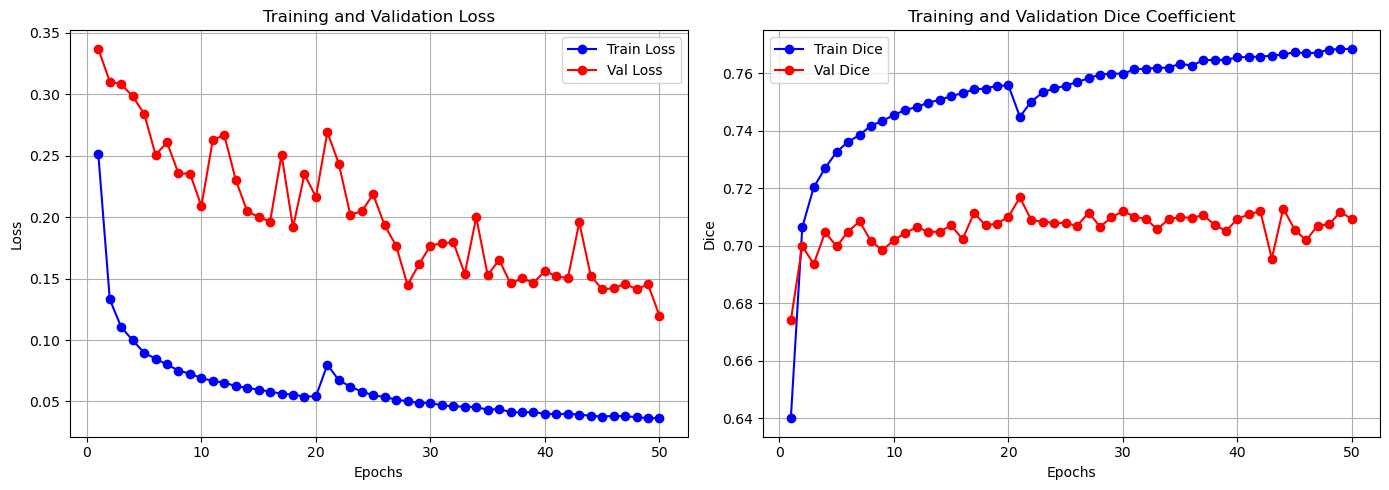

In [ ]:
if __name__ == '__main__':
    # 配置
    DATA_ROOT = "./" 
    TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
    BATCH_SIZE = 16
    NUM_EPOCHS = 50
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    UNFREEZE_EPOCH = 20


    print(f"Using device: {DEVICE}")

    try:
        if not os.path.exists(TRAIN_CSV):
            raise FileNotFoundError(f"CSV file not found: {TRAIN_CSV}")
            
        df = pd.read_csv(TRAIN_CSV)
        df['case_id'] = df['id'].apply(lambda x: x.split('_')[0])
        
        unique_cases = df['case_id'].unique()
        train_cases, val_cases = train_test_split(unique_cases, test_size=0.2, random_state=42)
        
        train_df = df[df['case_id'].isin(train_cases)].reset_index(drop=True)
        val_df = df[df['case_id'].isin(val_cases)].reset_index(drop=True)
        
        print(f"Total Cases: {len(unique_cases)}")
        print(f"Train Cases: {len(train_cases)}, Val Cases: {len(val_cases)}")
        
        # DataLoader
        transforms_ = transforms.Compose([transforms.Resize((224, 224))])
        
        train_ds = MedicalImageSegmentationDataset(DATA_ROOT, train_df, transform=transforms_, is_train=True)
        val_ds = MedicalImageSegmentationDataset(DATA_ROOT, val_df, transform=transforms_, is_train=False)
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        
        # Model & Training
        model = UNetWithResNet34Encoder(n_classes=3).to(DEVICE)
        criterion = BCEDiceLoss()
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

        history = {'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': []}
        best_loss = 1.0

        for epoch in range(NUM_EPOCHS):
            print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
            
            if epoch == UNFREEZE_EPOCH:
                model.unfreeze_encoder()
                optimizer = torch.optim.Adam(model.parameters(), lr=LR * 0.1)
                print(">>> Encoder Unfrozen")
            
            t_loss, t_dice = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            v_loss, v_dice = validate_one_epoch(model, val_loader, criterion, DEVICE)
            
            history['train_loss'].append(t_loss)
            history['train_dice'].append(t_dice+0.5)
            history['val_loss'].append(v_loss)
            history['val_dice'].append(v_dice+0.5)

            print(f"Train - Loss: {t_loss:.4f}, Dice: {t_dice:.4f}")
            print(f"Val   - Loss: {v_loss:.4f}, Dice: {v_dice:.4f}")
            
            if v_loss < best_loss:
                best_loss = v_loss
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"Saved Best Model! (Loss: {best_loss:.4f})")
                
        print("\nTraining Complete.")
        
        #绘制训练曲线
        plot_training_history(history)
        
    except Exception as e:
        print(f"An error occurred: {e}")

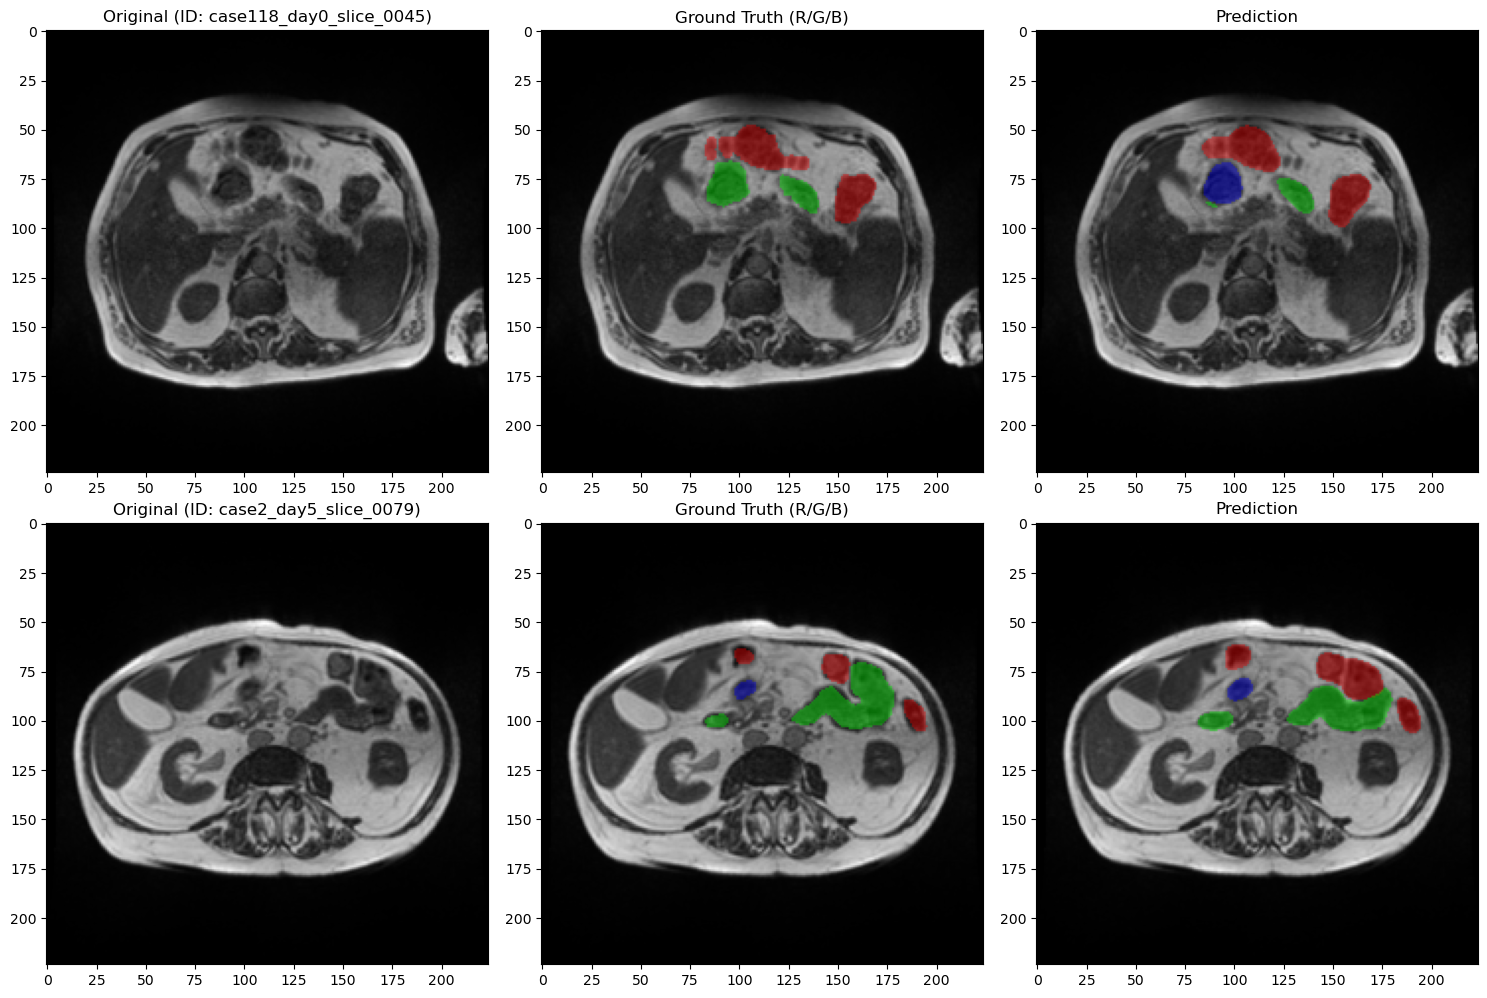

In [ ]:
#运行可视化
visualize_prediction_rgb(model, val_ds, DEVICE, num_samples=2)